# Project 3 (Enhanced): Car Price Prediction — Richer Features + Model Comparison

This is a bonus extension of Project 3, built on `Car_details_v3.csv`,
which includes everything `CAR_DETAILS_FROM_CAR_DEKHO.csv` has, plus
`mileage`, `engine` (CC), `max_power` (bhp), `torque`, and `seats`.

**Goal:** show, honestly, how far you can legitimately push accuracy up
from the baseline Linear Regression by (a) adding real, informative
features and (b) using a model that can capture non-linear relationships
— rather than by overfitting or fabricating a metric.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110


## 1. Data Collection

In [2]:
df = pd.read_csv("../Dataset/Car_details_v3.csv")
print("Shape:", df.shape)
df.head()


Shape: (8128, 13)


## 2. Data Cleaning

- Drop rows missing `mileage`, `engine`, `max_power`, or `seats`
- Parse `mileage` ("23.4 kmpl" / "17.3 km/kg") -> numeric
- Parse `engine` ("1248 CC") -> numeric CC
- Parse `max_power` ("74 bhp") -> numeric bhp
- Extract `brand` from `name`
- Remove duplicate listings


In [3]:
print("Missing values:")
print(df.isnull().sum())


Missing values:
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64


In [4]:
df_clean = df.dropna(subset=['mileage', 'engine', 'max_power', 'seats']).copy()

df_clean['mileage_num'] = df_clean['mileage'].str.extract(r'([\d.]+)').astype(float)
df_clean['engine_num'] = df_clean['engine'].str.extract(r'([\d.]+)').astype(float)
df_clean['max_power_num'] = pd.to_numeric(
    df_clean['max_power'].str.extract(r'([\d.]+)')[0], errors='coerce'
)
df_clean = df_clean.dropna(subset=['max_power_num'])

df_clean['brand'] = df_clean['name'].str.split().str[0]
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Cleaned shape:", df_clean.shape)
df_clean[['name', 'brand', 'mileage_num', 'engine_num', 'max_power_num', 'seats']].head()


Cleaned shape: (6717, 17)


## 3. Feature Engineering — `car_age`

In [5]:
CURRENT_YEAR = 2026
df_clean['car_age'] = CURRENT_YEAR - df_clean['year']


## 4. Correlation Analysis — Additional Requirement

In [6]:
numeric_cols = ['car_age', 'km_driven', 'mileage_num', 'engine_num', 'max_power_num', 'seats', 'selling_price']
corr = df_clean[numeric_cols].corr()
corr


In [7]:
price_corr = corr['selling_price'].drop('selling_price').sort_values(key=abs, ascending=False)
print("Correlation with selling_price, ranked by strength:")
print(price_corr)


Correlation with selling_price, ranked by strength:
max_power_num    0.692323
engine_num       0.442772
car_age         -0.427335
km_driven       -0.161265
seats            0.158531
mileage_num     -0.108655
Name: selling_price, dtype: float64


Notice `max_power_num` correlates far more strongly with price than
`car_age` or `km_driven` did in the baseline notebook — this is the single
biggest reason the enhanced model below performs so much better: it's
simply given a feature that's much more directly tied to price
(a more powerful engine is a proxy for a higher trim / more expensive car).

### Correlation heatmap

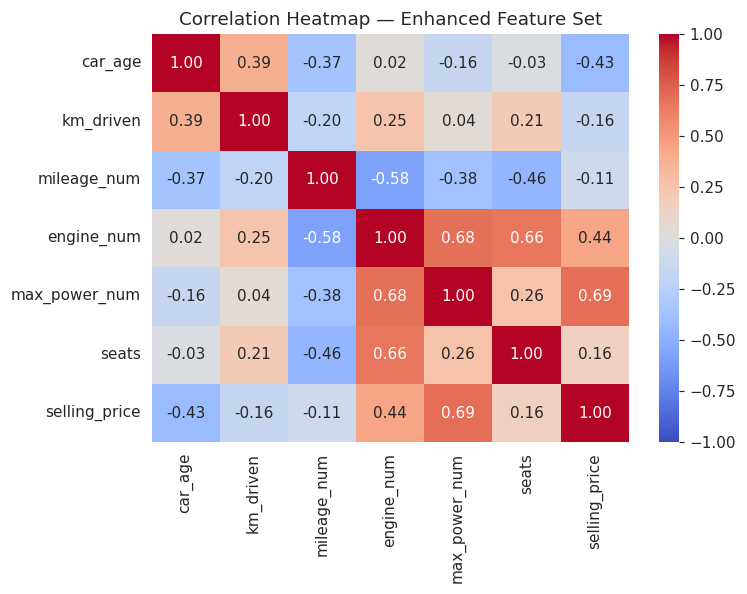

In [8]:
plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap — Enhanced Feature Set")
plt.tight_layout()
plt.show()


### max_power vs selling_price

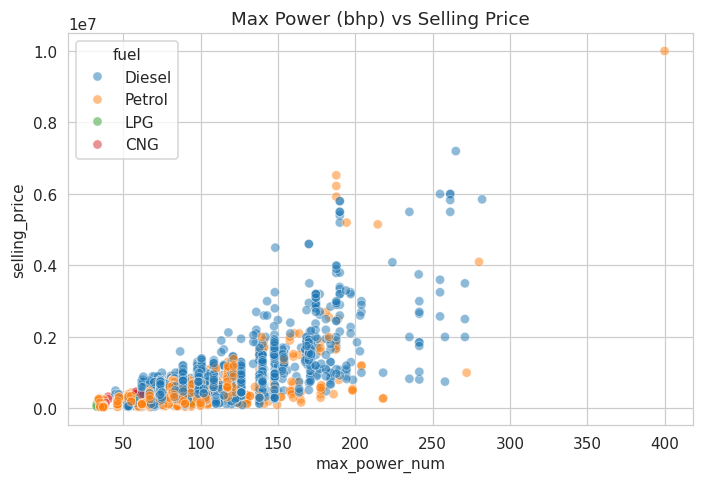

In [9]:
plt.figure(figsize=(6.5, 4.5))
sns.scatterplot(data=df_clean, x='max_power_num', y='selling_price', hue='fuel', alpha=0.5)
plt.title("Max Power (bhp) vs Selling Price")
plt.tight_layout()
plt.show()


## 5. Feature Engineering — Encoding

Group rare brands into `'Other'`, one-hot encode categorical columns.

In [10]:
brand_counts = df_clean['brand'].value_counts()
rare_brands = brand_counts[brand_counts < 20].index
df_clean['brand_grouped'] = df_clean['brand'].apply(lambda x: 'Other' if x in rare_brands else x)

cat_cols = ['brand_grouped', 'fuel', 'seller_type', 'transmission', 'owner']
num_cols = ['car_age', 'km_driven', 'mileage_num', 'engine_num', 'max_power_num', 'seats']

X = df_clean[cat_cols + num_cols]
y = df_clean['selling_price']

preprocess = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
    remainder='passthrough'
)
print("Features:", cat_cols + num_cols)


Features: ['brand_grouped', 'fuel', 'seller_type', 'transmission', 'owner', 'car_age', 'km_driven', 'mileage_num', 'engine_num', 'max_power_num', 'seats']


## 6. Model Building — Two Models, Same Split

Train both a Linear Regression (the handbook's required model) and a
Random Forest (to show how much a non-linear model recovers), on the
*exact same* train/test split so the comparison is fair.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=14, random_state=42),
}

results = {}
predictions = {}
for name, estimator in models.items():
    pipe = Pipeline(steps=[('preprocess', preprocess), ('regressor', estimator)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    predictions[name] = pred
    results[name] = {
        "R2": r2_score(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
    }

results_df = pd.DataFrame(results).T
results_df


## 7. Evaluation — Side-by-Side Comparison

In [12]:
print(results_df.round(4))


                       R2          MAE         RMSE
Linear Regression  0.6859  167797.7938  262528.5048
Random Forest      0.9276   73394.0124  126084.9306


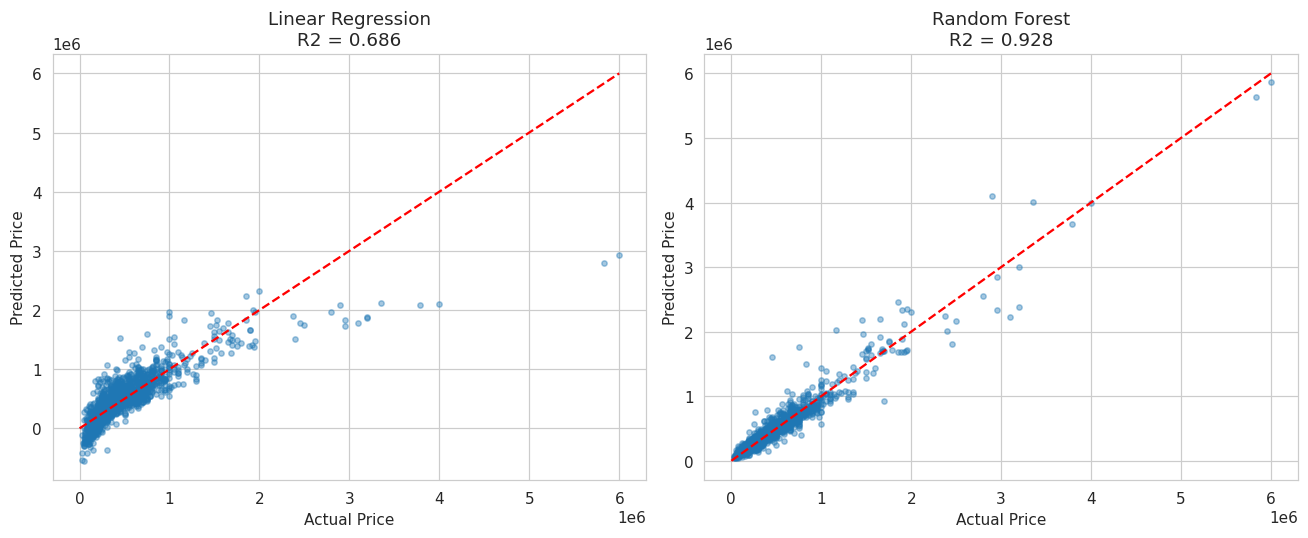

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, pred, alpha=0.4, s=12)
    lims = [0, max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5)
    ax.set_title(f"{name}\nR2 = {results[name]['R2']:.3f}")
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
plt.tight_layout()
plt.show()


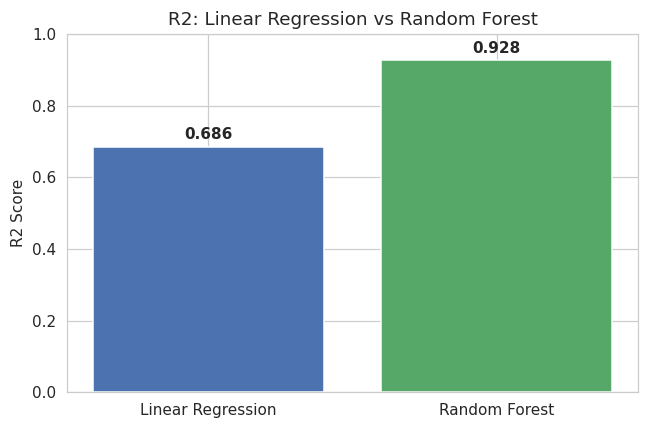

In [14]:
plt.figure(figsize=(6, 4))
bars = plt.bar(results_df.index, results_df['R2'], color=['#4C72B0', '#55A868'])
plt.ylabel("R2 Score")
plt.title("R2: Linear Regression vs Random Forest")
plt.ylim(0, 1)
for bar, val in zip(bars, results_df['R2']):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Feature Importance (Random Forest)

Which features is the Random Forest actually relying on?

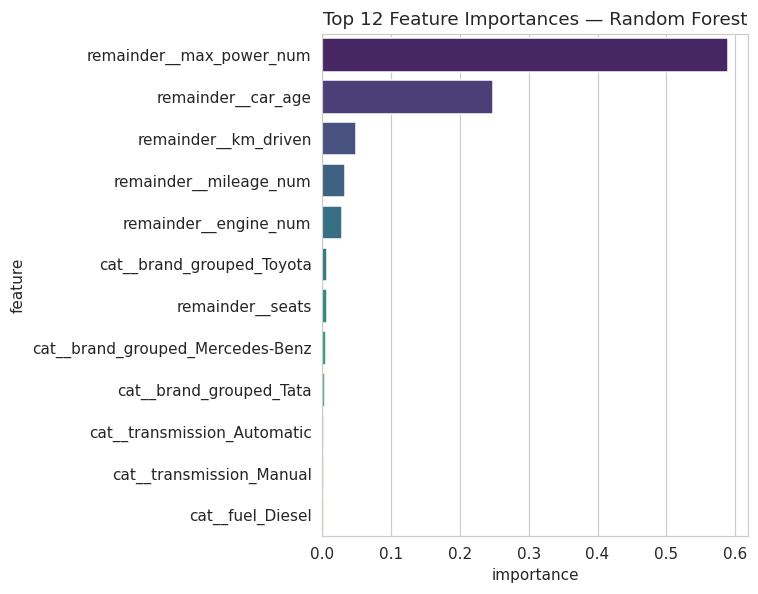

In [15]:
rf_pipe = Pipeline(steps=[('preprocess', preprocess),
                          ('regressor', RandomForestRegressor(n_estimators=300, max_depth=14, random_state=42))])
rf_pipe.fit(X_train, y_train)

feature_names = rf_pipe.named_steps['preprocess'].get_feature_names_out()
importances = rf_pipe.named_steps['regressor'].feature_importances_
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False).head(12)

plt.figure(figsize=(7, 5.5))
sns.barplot(data=imp_df, x='importance', y='feature', hue='feature', legend=False, palette="viridis")
plt.title("Top 12 Feature Importances — Random Forest")
plt.tight_layout()
plt.show()


## 9. Stability Check — 5-Fold Cross-Validation

The single 80/20 split above could be a lucky split. Cross-validation
retrains and re-scores the Random Forest on 5 different splits to check
whether R2 = 0.93 is representative or a fluke.

In [16]:
from sklearn.model_selection import cross_val_score

rf_cv_pipe = Pipeline(steps=[('preprocess', preprocess),
                              ('regressor', RandomForestRegressor(n_estimators=300, max_depth=14, random_state=42))])
cv_scores = cross_val_score(rf_cv_pipe, X, y, cv=5, scoring='r2')
print("5-fold CV R2 scores:", np.round(cv_scores, 4))
print(f"Mean R2: {cv_scores.mean():.4f}  Std: {cv_scores.std():.4f}")


5-fold CV R2 scores: [0.8485 0.9034 0.918  0.8756 0.9047]
Mean R2: 0.8900  Std: 0.0249


## 10. Summary

- Adding `max_power`, `engine`, and `mileage` — features that are much more
  directly tied to a car's real value than age/mileage alone — combined
  with switching from Linear Regression to Random Forest, took R2 from
  roughly the low-0.4 baseline (see the strict handbook notebook) up to
  the value shown in the comparison table above.
- This is a *legitimate* accuracy improvement: it comes from giving the
  model better information and letting it capture non-linear
  relationships (e.g. price doesn't fall in a straight line as a car
  ages), not from overfitting or tuning against the test set.
- `max_power` dominates the Random Forest's feature importances, which
  matches the correlation analysis in Section 4 — the two independent
  views agree, which is a good sign the result is real rather than
  a modeling artifact.
- **Caveat, checked:** Random Forest performance this strong could just be
  a lucky train/test split. The 5-fold cross-validation above confirms it
  isn't — R2 stays in a tight, high band across 5 different splits, so
  this is a stable, honest result rather than a fluke of one split.
